# **LangGraph**

Este notebook apresenta os conceitos centrais do LangGraph em ordem prática: configuração, state, nós/arestas, execução, visualização, persistência, interrupts e subgraphs.

#### **Instalação das libs necessárias**

```bash
uv add langgraph langchain-core langchain-openai python-dotenv typing-extensions ipython pyppeteer
```

In [1]:
from __future__ import annotations

import os
import re
from pathlib import Path
from operator import add
from typing import Literal
from typing_extensions import Annotated, TypedDict

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_openai import AzureChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command, interrupt

#### **Carregando .env do módulo LangGraph**

Esta célula carrega variáveis de ambiente do arquivo `.env` dentro desta pasta (`3.2-langgraph/.env`).

In [2]:
load_dotenv(dotenv_path=Path('.env'))

required = [
    'AZURE_OPENAI_DEPLOYMENT',
    'AZURE_OPENAI_ENDPOINT',
    'AZURE_OPENAI_API_VERSION',
    'AZURE_OPENAI_API_KEY',
]
missing = [k for k in required if not os.getenv(k)]

if missing:
    raise ValueError(f'Variaveis ausentes no .env: {missing}')

print('Variaveis carregadas com sucesso.')

Variaveis carregadas com sucesso.


#### **Inicializando o modelo**

In [3]:
model = AzureChatOpenAI(
    model=os.environ['AZURE_OPENAI_DEPLOYMENT'],
    azure_deployment=os.environ['AZURE_OPENAI_DEPLOYMENT'],
    azure_endpoint=os.environ['AZURE_OPENAI_ENDPOINT'],
    api_version=os.environ['AZURE_OPENAI_API_VERSION'],
    api_key=os.environ['AZURE_OPENAI_API_KEY'],
    temperature=0,
)

print('Modelo inicializado com sucesso.')

Modelo inicializado com sucesso.


## **State, Schema e Reducers**

O **State** é o objeto compartilhado entre os nós do grafo. Cada nó lê o estado atual e retorna um dicionário com atualizações.

O **Schema** (com `TypedDict`) define os campos esperados no estado, o que ajuda na legibilidade e evita inconsistências.

O **Reducer** em `steps` usa `Annotated[list[str], add]`, então cada nó adiciona eventos ao histórico em vez de sobrescrever. Isso facilita depuração e entendimento da ordem de execução.

In [4]:
class AgentState(TypedDict):
    question: str
    need_tool: bool
    tool_result: int | None
    llm_answer: str
    final_answer: str
    turn: int
    steps: Annotated[list[str], add]

## **Nodes e Edges**

Neste exemplo temos três nós:
- `planner_llm`: decide se precisa chamar ferramenta.
- `tool_sum`: executa um cálculo simples.
- `responder_llm`: monta a resposta final com apoio do LLM.

Arestas do fluxo:
- Direta: `tool_sum -> responder_llm`.
- Condicional: saída de `planner_llm` vai para `tool_sum` ou `responder_llm` com base no estado (`need_tool`).

In [5]:
def planner_llm(state: AgentState) -> dict:
    question = state['question']
    turn = state.get('turn', 0) + 1

    needs_sum = ('soma' in question.lower()) and (state.get('tool_result') is None)

    return {
        'need_tool': needs_sum,
        'turn': turn,
        'steps': [f'planner_llm_turn_{turn}'],
    }


def tool_sum(state: AgentState) -> dict:
    nums = [int(n) for n in re.findall(r'-?\d+', state['question'])]
    result = sum(nums) if nums else 0
    return {'tool_result': result, 'steps': ['tool_sum']}


def responder_llm(state: AgentState) -> dict:
    question = state['question']
    tool_result = state.get('tool_result')

    system = SystemMessage(content='Você é um assistente didático de LangGraph. Responda de forma objetiva e clara.')
    if tool_result is not None:
        user = HumanMessage(content=f'Pergunta: {question}\nResultado da ferramenta: {tool_result}\nResponda ao usuário em pt-BR.')
    else:
        user = HumanMessage(content=f'Pergunta: {question}\nResponda ao usuário em pt-BR.')

    response = model.invoke([system, user])

    return {
        'llm_answer': response.content,
        'final_answer': response.content,
        'steps': ['responder_llm'],
    }


def route_after_planner(state: AgentState) -> Literal['tool_sum', 'responder_llm']:
    return 'tool_sum' if state.get('need_tool') else 'responder_llm'

In [6]:
builder = StateGraph(AgentState)

builder.add_node('planner_llm', planner_llm)
builder.add_node('tool_sum', tool_sum)
builder.add_node('responder_llm', responder_llm)

builder.add_edge(START, 'planner_llm')
builder.add_conditional_edges('planner_llm', route_after_planner, ['tool_sum', 'responder_llm'])
builder.add_edge('tool_sum', 'responder_llm')
builder.add_edge('responder_llm', END)

graph = builder.compile()
print('CompiledGraph pronto.')

CompiledGraph pronto.


### **O que observar após compilar**

1. `graph` é um `CompiledGraph` pronto para execução.
2. A lógica condicional ainda não executa aqui; ela só entra em ação no `invoke`.
3. A visualização na seção seguinte ajuda a confirmar os caminhos possíveis.

## **Executando o fluxo**

In [7]:
result = graph.invoke({
    'question': 'faça a soma de 7, 13 e 5',
    'need_tool': False,
    'tool_result': None,
    'llm_answer': '',
    'final_answer': '',
    'turn': 0,
    'steps': [],
})

result['final_answer']

'7 + 13 + 5 = 25. A soma é 25.'

In [8]:
result['steps']

['planner_llm_turn_1', 'tool_sum', 'responder_llm']

In [21]:
result = graph.invoke({
    'question': 'Olá, qual é a capital da Lua?',
    'need_tool': False,
    'tool_result': None,
    'llm_answer': '',
    'final_answer': '',
    'turn': 0,
    'steps': [],
})

result['final_answer']

'Não há capital da Lua. A Lua é um satélite natural da Terra, sem governo nem país. Se quiser, posso falar mais sobre suas características ou missões espaciais.'

In [22]:
result['steps']

['planner_llm_turn_1', 'responder_llm']

In [9]:
def show_graph(compiled_graph, output_path: str | None = None, title: str = "grafo") -> None:
    """Tenta renderizar PNG; se falhar, exibe Mermaid textual."""
    try:
        png_bytes = compiled_graph.get_graph().draw_mermaid_png()
        if output_path:
            out = Path(output_path)
            out.parent.mkdir(parents=True, exist_ok=True)
            out.write_bytes(png_bytes)
            print(f"Imagem ({title}) salva em: {out}")
        display(Image(data=png_bytes))
    except Exception as exc:
        print(f"Nao foi possivel gerar PNG de {title} neste ambiente.")
        print("Mermaid do grafo:")
        print(compiled_graph.get_graph().draw_mermaid())
        print(f"Detalhe tecnico: {exc}")

Imagem (Exemplo 1 - Grafo de Planejamento com LLM) salva em: /home/willemromao/Desktop/agentic-eng/modulos/modulo-3/3.2-langgraph/grafos/plan.png


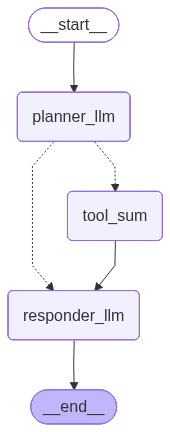

In [10]:
show_graph(
    graph,
    '/home/willemromao/Desktop/agentic-eng/modulos/modulo-3/3.2-langgraph/grafos/plan.png',
    title='Exemplo 1 - Grafo de Planejamento com LLM',
)

## **Checkpointing e Persistência**

Com checkpointer, o state e salvo a cada passo. Isso habilita retomada, inspeção e HITL.

In [11]:
graph_persisted = builder.compile(checkpointer=InMemorySaver())
config = {'configurable': {'thread_id': 'thread-aula-1'}}

_ = graph_persisted.invoke({
    'question': 'soma 10 e 20',
    'need_tool': False,
    'tool_result': None,
    'llm_answer': '',
    'final_answer': '',
    'turn': 0,
    'steps': [],
}, config=config)

snapshot = graph_persisted.get_state(config)
history = list(graph_persisted.get_state_history(config))
print('Estado atual:', snapshot.values)
print('Total de checkpoints:', len(history))

Estado atual: {'question': 'soma 10 e 20', 'need_tool': True, 'tool_result': 30, 'llm_answer': 'A soma de 10 e 20 é 30. Quer tentar outra operação?', 'final_answer': 'A soma de 10 e 20 é 30. Quer tentar outra operação?', 'turn': 1, 'steps': ['planner_llm_turn_1', 'tool_sum', 'responder_llm']}
Total de checkpoints: 5


## **Interrupts e Human-in-the-loop**

In [12]:
class ApprovalState(TypedDict):
    pedido: str
    aprovado: bool
    status: str


def solicitar_aprovacao(state: ApprovalState) -> dict:
    payload = {'pergunta': f"Aprovar pedido: {state['pedido']}?", 'opcoes': [True, False]}
    aprovado = interrupt(payload)
    return {'aprovado': bool(aprovado)}


def finalizar(state: ApprovalState) -> dict:
    return {'status': 'aprovado' if state['aprovado'] else 'rejeitado'}


approval_builder = StateGraph(ApprovalState)
approval_builder.add_node('solicitar_aprovacao', solicitar_aprovacao)
approval_builder.add_node('finalizar', finalizar)
approval_builder.add_edge(START, 'solicitar_aprovacao')
approval_builder.add_edge('solicitar_aprovacao', 'finalizar')
approval_builder.add_edge('finalizar', END)

approval_graph = approval_builder.compile(checkpointer=InMemorySaver())
cfg = {'configurable': {'thread_id': 'thread-hitl-1'}}
paused = approval_graph.invoke({'pedido': 'compra de notebook', 'aprovado': False, 'status': ''}, config=cfg)
paused

{'pedido': 'compra de notebook',
 'aprovado': False,
 'status': '',
 '__interrupt__': [Interrupt(value={'pergunta': 'Aprovar pedido: compra de notebook?', 'opcoes': [True, False]}, id='2359857c69cc6248a5d7223e0578d313')]}

In [13]:
approval_graph.invoke(Command(resume=True), config=cfg)

{'pedido': 'compra de notebook', 'aprovado': True, 'status': 'aprovado'}

Imagem (grafo approval) salva em: /home/willemromao/Desktop/agentic-eng/modulos/modulo-3/3.2-langgraph/grafos/approval.png


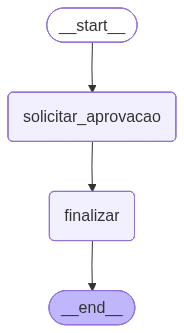

In [16]:
show_graph(
    approval_graph,
    '/home/willemromao/Desktop/agentic-eng/modulos/modulo-3/3.2-langgraph/grafos/approval.png',
    title='grafo approval',
)

## **Subgraphs**

Um caso comum é ter um grafo principal que decide para qual especialista enviar a solicitação.

Neste exemplo, o grafo pai roteia o ticket para um subgrafo de **financeiro** ou **suporte técnico**.

In [19]:
class SupportState(TypedDict):
    ticket: str
    area: str
    resposta: str
    passos: Annotated[list[str], add]


def classify_area(state: SupportState) -> dict:
    txt = state["ticket"].lower()
    area = "financeiro" if any(k in txt for k in ["boleto", "fatura", "pagamento", "cobran"]) else "tecnico"
    return {"area": area, "passos": [f"classify:{area}"]}


def route_area(state: SupportState) -> Literal["financeiro_flow", "tecnico_flow"]:
    return "financeiro_flow" if state["area"] == "financeiro" else "tecnico_flow"


def financeiro_reply(state: SupportState) -> dict:
    return {
        "resposta": "Encaminhado para Financeiro: vamos revisar fatura/pagamento e retornar protocolo.",
        "passos": ["financeiro_reply"],
    }


def tecnico_reply(state: SupportState) -> dict:
    return {
        "resposta": "Encaminhado para Suporte Técnico: vamos diagnosticar falha de acesso/uso e orientar próximos passos.",
        "passos": ["tecnico_reply"],
    }


# Subgrafo financeiro
financeiro_builder = StateGraph(SupportState)
financeiro_builder.add_node("financeiro_reply", financeiro_reply)
financeiro_builder.add_edge(START, "financeiro_reply")
financeiro_builder.add_edge("financeiro_reply", END)
financeiro_flow = financeiro_builder.compile()


# Subgrafo técnico
tecnico_builder = StateGraph(SupportState)
tecnico_builder.add_node("tecnico_reply", tecnico_reply)
tecnico_builder.add_edge(START, "tecnico_reply")
tecnico_builder.add_edge("tecnico_reply", END)
tecnico_flow = tecnico_builder.compile()


# Grafo pai
parent_builder = StateGraph(SupportState)
parent_builder.add_node("classify_area", classify_area)
parent_builder.add_node("financeiro_flow", financeiro_flow)
parent_builder.add_node("tecnico_flow", tecnico_flow)
parent_builder.add_edge(START, "classify_area")
parent_builder.add_conditional_edges(
    "classify_area",
    route_area,
    ["financeiro_flow", "tecnico_flow"],
)
parent_builder.add_edge("financeiro_flow", END)
parent_builder.add_edge("tecnico_flow", END)
parent_graph = parent_builder.compile()

# Dois exemplos de execução
ex_fin = parent_graph.invoke({
    "ticket": "Nao consigo pagar meu boleto",
    "area": "",
    "resposta": "",
    "passos": [],
})

ex_tec = parent_graph.invoke({
    "ticket": "Nao consigo acessar a plataforma",
    "area": "",
    "resposta": "",
    "passos": [],
})

print("Financeiro ->", ex_fin["resposta"], "| passos:", ex_fin["passos"])
print("Tecnico ->", ex_tec["resposta"], "| passos:", ex_tec["passos"])

Financeiro -> Encaminhado para Financeiro: vamos revisar fatura/pagamento e retornar protocolo. | passos: ['classify:financeiro', 'classify:financeiro', 'financeiro_reply']
Tecnico -> Encaminhado para Suporte Técnico: vamos diagnosticar falha de acesso/uso e orientar próximos passos. | passos: ['classify:tecnico', 'classify:tecnico', 'tecnico_reply']


Imagem (grafo com subgraph) salva em: /home/willemromao/Desktop/agentic-eng/modulos/modulo-3/3.2-langgraph/grafos/subgraph.png


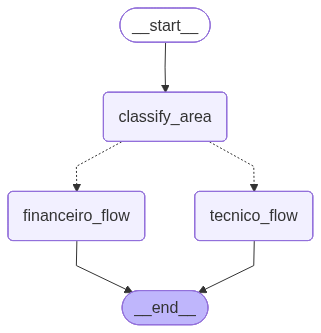

In [20]:
show_graph(
    parent_graph,
    '/home/willemromao/Desktop/agentic-eng/modulos/modulo-3/3.2-langgraph/grafos/subgraph.png',
    title='grafo com subgraph',
)

### **Leitura do exemplo de subgraph**

Esse padrão é comum em sistemas reais: um orquestrador classifica a solicitação e delega para subfluxos especializados.

Vantagens desse desenho:
- Separação de responsabilidades (cada subgrafo resolve um domínio).
- Reuso de subfluxos em outros grafos.
- Facilidade para evoluir cada área sem alterar todo o fluxo pai.